# 2D transient heat conduction (implicit Euler) — FOM + ROM

This example follows the same workflow as other scikit-rom examples:
1) Offline full-order solves to generate snapshots
2) POD basis generation (SVD) on mean-subtracted training data
3) Online reduced-order solves and error/speed-up evaluation


## Environment setup

In [1]:
import sys
from pathlib import Path
import importlib

nb_folder = Path().resolve()
PROBLEM_NAME = nb_folder.name
parent_folder = nb_folder.parent
if str(parent_folder) not in sys.path:
    sys.path.insert(0, str(parent_folder))


In [2]:
from skrom.utils.imports import *
from skrom.rom.rom_utils import *
from skrom.utils.reduced_basis.svd import svd_mode_selector
import skrom.problem_classes.masterclass as master
problem_mod = importlib.import_module(f"{PROBLEM_NAME}.problem_def")
from skrom.rom.rom_error_est_t import *


PETSc available: True


In [3]:
import sci_mplstyle_package

In [ ]:
generate_data = True
visualize = False
run_svd = True
run_rom = True
rom_report = True

## Full-order simulation (offline snapshots)

In [5]:
if generate_data:
    sim = master.fom_simulation(num_snapshots=16)
    sim.run_simulation()


Transforming over 1000 elements to C_CONTIGUOUS.
Transforming over 1000 elements to C_CONTIGUOUS.


Snap 1/32 params=[2.05661222 1.52686914]
Snap 2/32 params=[2.89479185 4.48956391]
Snap 3/32 params=[4.05801425 0.97335369]
Snap 4/32 params=[1.22834826 3.01060411]
Snap 5/32 params=[0.71008682 0.53965141]
Snap 6/32 params=[4.61523063 3.44362012]
Snap 7/32 params=[3.60629206 1.95986569]
Snap 8/32 params=[1.38406666 4.05588034]
Snap 9/32 params=[1.73079507 0.92047141]
Snap 10/32 params=[3.18231592 2.59412157]
Snap 11/32 params=[4.9571809  1.57911483]
Snap 12/32 params=[0.2908935  4.90544326]
Snap 13/32 params=[0.958173   2.39604191]
Snap 14/32 params=[4.25229355 4.08905046]
Snap 15/32 params=[2.62939474 0.10409747]
Snap 16/32 params=[2.24610869 3.41102934]
Snap 17/32 params=[0.74405755 3.37186068]
Snap 18/32 params=[2.65652644 0.84724229]
Snap 19/32 params=[4.54416517 4.36516557]
Snap 20/32 params=[1.55659697 1.73311434]
Snap 21/32 params=[2.17468789 4.92692939]
Snap 22/32 params=[3.93429339 2.41221433]
Snap 23/32 params=[3.27593116 2.80506146]
Snap 24/32 params=[0.13557435 0.16341208]
S

### Load Simulation Data

In [19]:
# Load saved ROM_data (works even if 'generate=False')
rom_data = master.rom_simulation()

[load_rom_data] loaded from d:\One_drive_folder\OneDrive - Indian Institute of Technology Indian School of Mines Dhanbad\IIT_ISM\RESEARCH\SCIKIT-ROM\scikit-rom\examples\heat_transfer\dynamic\problem_transient_heat_2d\ROM_data


## POD basis (stack all time instants across training parameters)

In [20]:
# Training snapshots and mean field
T_train = rom_data.fos_solutions[rom_data.train_mask]          # (n_train, nt, Nh)
T_ref  = T_train[:,0:1,:] 

In [21]:
T_train_ms = T_train - T_ref  

Number of modes selected: 3
Selected modes: 3  | Nh: 676


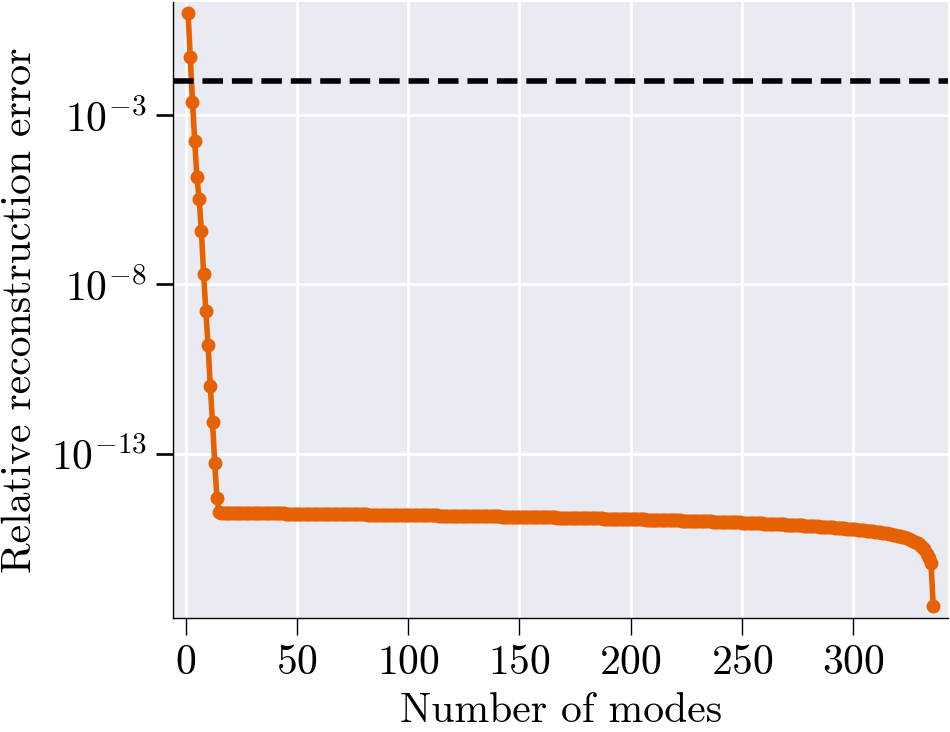

In [22]:
if run_svd:

    plt.rcParams['lines.markersize'] = 6
    plt.rcParams['lines.linewidth'] = 2.0
    
    # Stack time and parameter snapshots into a 2D matrix for SVD
    X = T_train_ms.reshape(-1, T_train_ms.shape[-1])              # (n_train*nt, Nh)

    n_sel, U = svd_mode_selector(X, tolerance=1e-2, modes=True)
    V_sel = U[:, :n_sel]
    print('Selected modes:', n_sel, ' | Nh:', V_sel.shape[0])


## ROM simulation (online)

In [26]:
if run_rom:
    rom = master.rom_simulation(V_sel=V_sel, n_sel=n_sel, train_ref=T_ref, test_ref=T_ref)
    rom_error, speed_up = rom.run_rom_simulation()
    print('Mean ROM error (%):', np.mean(rom_error))
    print('Mean speed-up:', np.mean(speed_up))


[load_rom_data] loaded from d:\One_drive_folder\OneDrive - Indian Institute of Technology Indian School of Mines Dhanbad\IIT_ISM\RESEARCH\SCIKIT-ROM\scikit-rom\examples\heat_transfer\dynamic\problem_transient_heat_2d\ROM_data
Snap 1/16 params=[0.74405755 3.37186068]
Snap 2/16 params=[2.65652644 0.84724229]
Snap 3/16 params=[4.54416517 4.36516557]
Snap 4/16 params=[1.55659697 1.73311434]
Snap 5/16 params=[2.17468789 4.92692939]
Snap 6/16 params=[3.93429339 2.41221433]
Snap 7/16 params=[3.27593116 2.80506146]
Snap 8/16 params=[0.13557435 0.16341208]
Snap 9/16 params=[0.63079757 3.7542495 ]
Snap 10/16 params=[3.76644429 1.40540522]
Snap 11/16 params=[4.12327275 3.51402674]
Snap 12/16 params=[2.35895656 1.01870141]
Snap 13/16 params=[1.75514167 2.82883992]
Snap 14/16 params=[4.73799978 0.45085554]
Snap 15/16 params=[3.16132494 4.43440092]
Snap 16/16 params=[1.24414536 1.96852087]
Mean ROM error (%): 0.017185978610078062
Mean speed-up: 11.718761078816268


## Quick visualization (one test case, final time)

In [27]:
if visualize:
    i = 0
    Tf = rom.fos_test_data[i][-1, :]
    Tr = rom.rom_solutions[i][-1, :]

    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    ax[0].tricontourf(rom.mesh.p[0], rom.mesh.p[1], Tf, levels=32)
    ax[0].set_title('FOM: $T\,(t_{end})$')
    ax[0].set_aspect('equal')

    ax[1].tricontourf(rom.mesh.p[0], rom.mesh.p[1], Tr, levels=32)
    ax[1].set_title('ROM: $T\,(t_{end})$')
    ax[1].set_aspect('equal')
    plt.tight_layout()
    plt.show()


## ROM Quality stats

In [28]:
if rom_report:
    matrix = compute_rom_error_metrics_flat(rom_data.fos_solutions[rom_data.test_mask] , np.asarray(rom.rom_solutions))
    # Produce a text-based report summarizing these hyper-ROM error metrics
    generate_rom_error_report(matrix)

ROM Accuracy Report

Global Errors:
L2 Error:                        8.9842e-04
Relative L2 Error:               1.3421e-04
L∞ Error:                        1.8671e-05
Relative L∞ Error:               1.5389e-04
RMSE:                            1.8851e-06
MAE:                             1.0194e-06

Statistical Fit:
R² Score:                        1.0000
Explained Variance:              1.0000

Error Distribution (absolute):
Median Abs Error:                4.4758e-07
95th Percentile Abs Error:       3.9653e-06

Time/Parameter-Dependent Errors:
Average Relative L2 over samples:        1.8387e-04
Max Relative L2 over samples:            8.6838e-03
Min Relative L2 over samples:            0.0000e+00
————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————


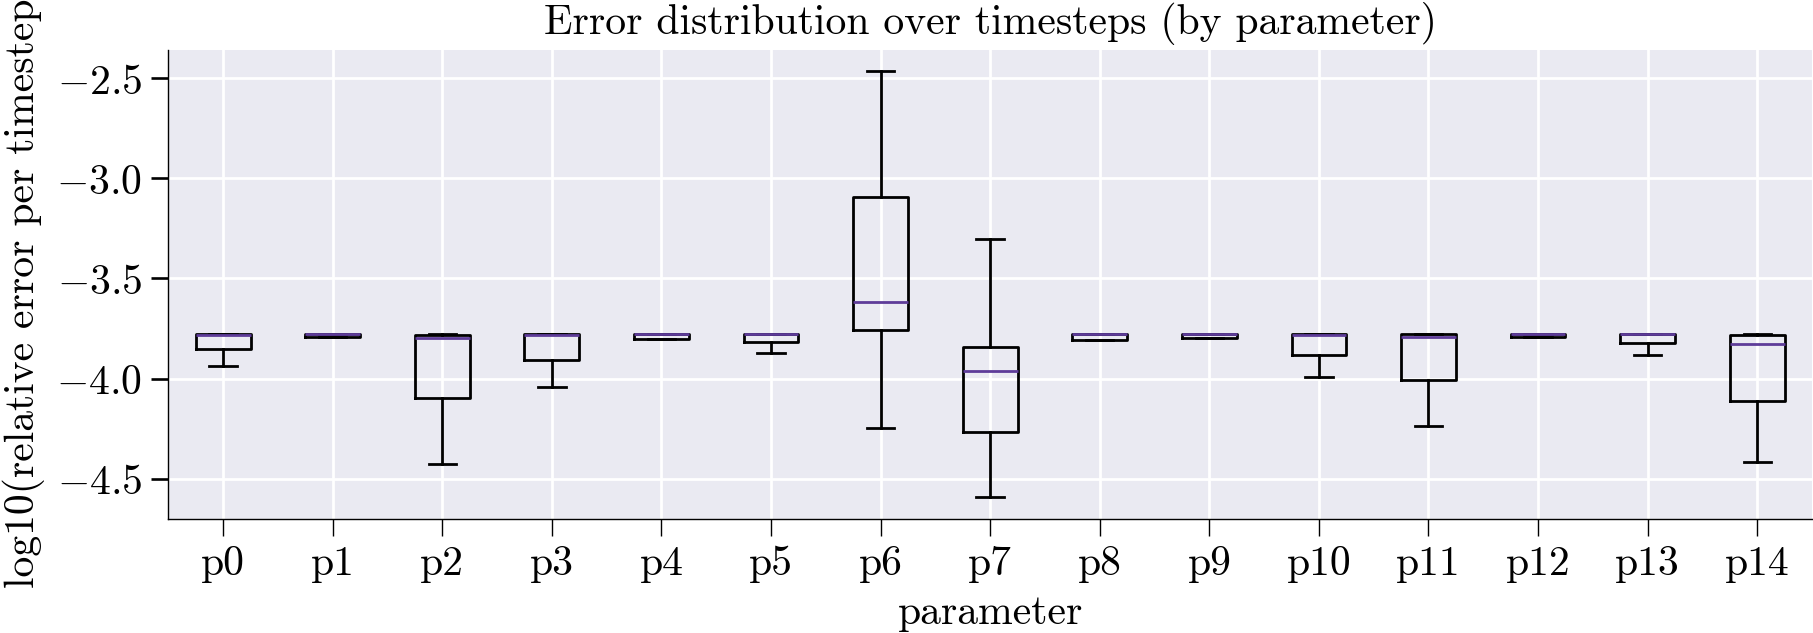

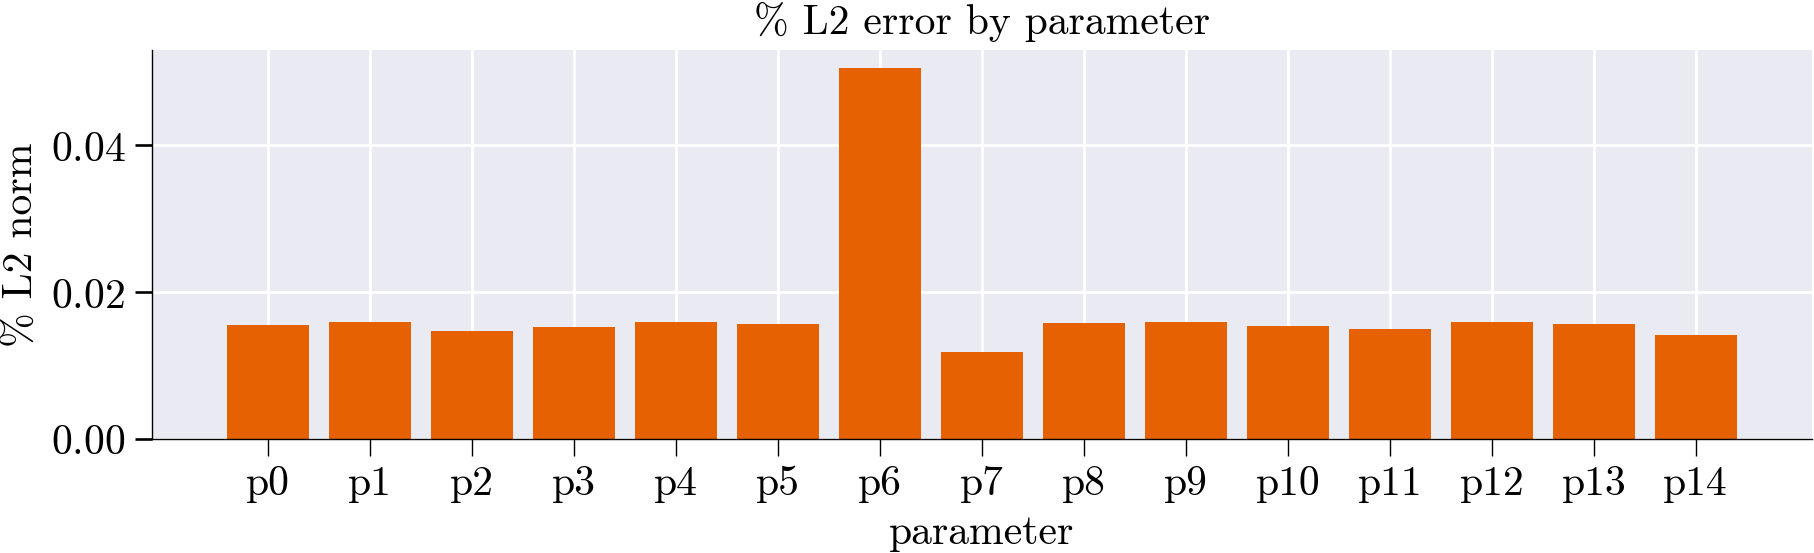

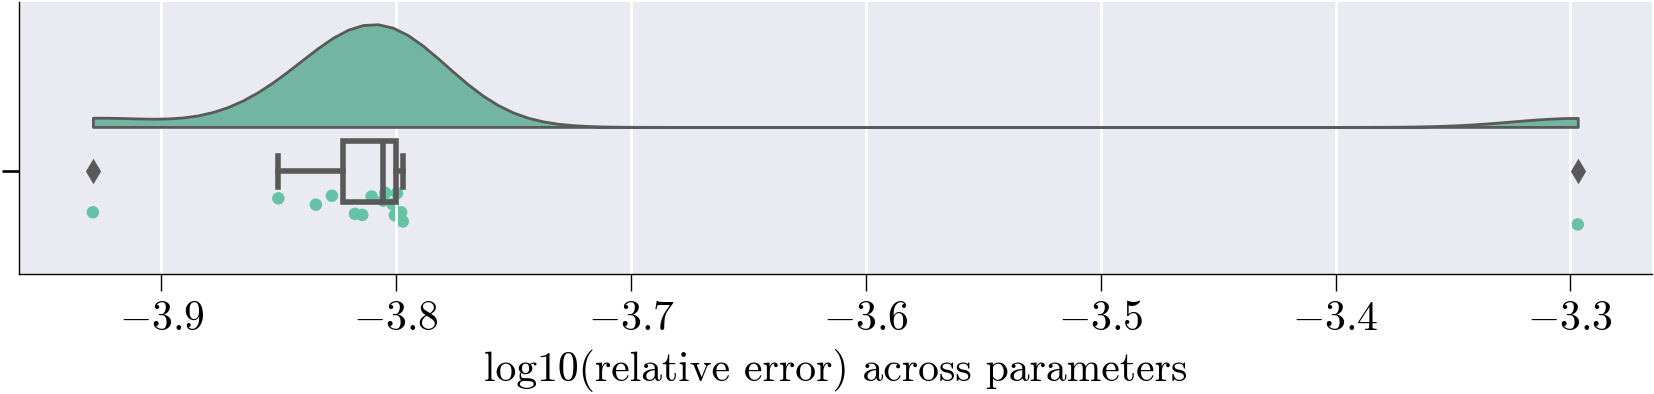

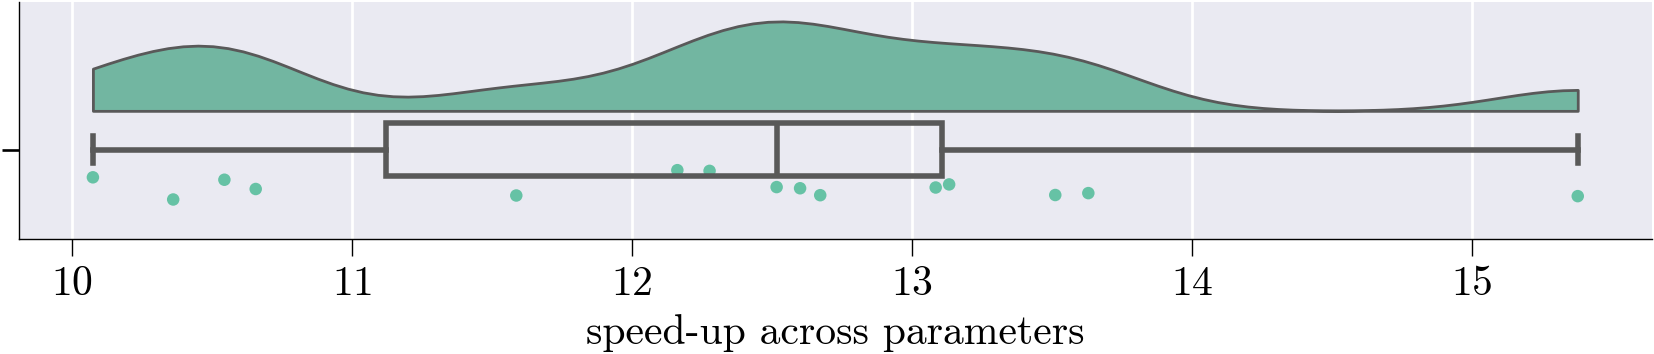

In [31]:
if rom_report:
    out = plot_rom_param_diagnostics_t(
        rom_data.fos_solutions[rom_data.test_mask][1:],
        np.asarray(rom.rom_solutions)[1:],
        l2_per_param=rom_error[1:],          # (p,)
        speedup_per_param=speed_up[1:], # (p,)
        param_labels=[f"p{i}" for i in range(rom_data.fos_solutions[rom_data.test_mask].shape[0]-1)],
        use_raincloud=True,
    )


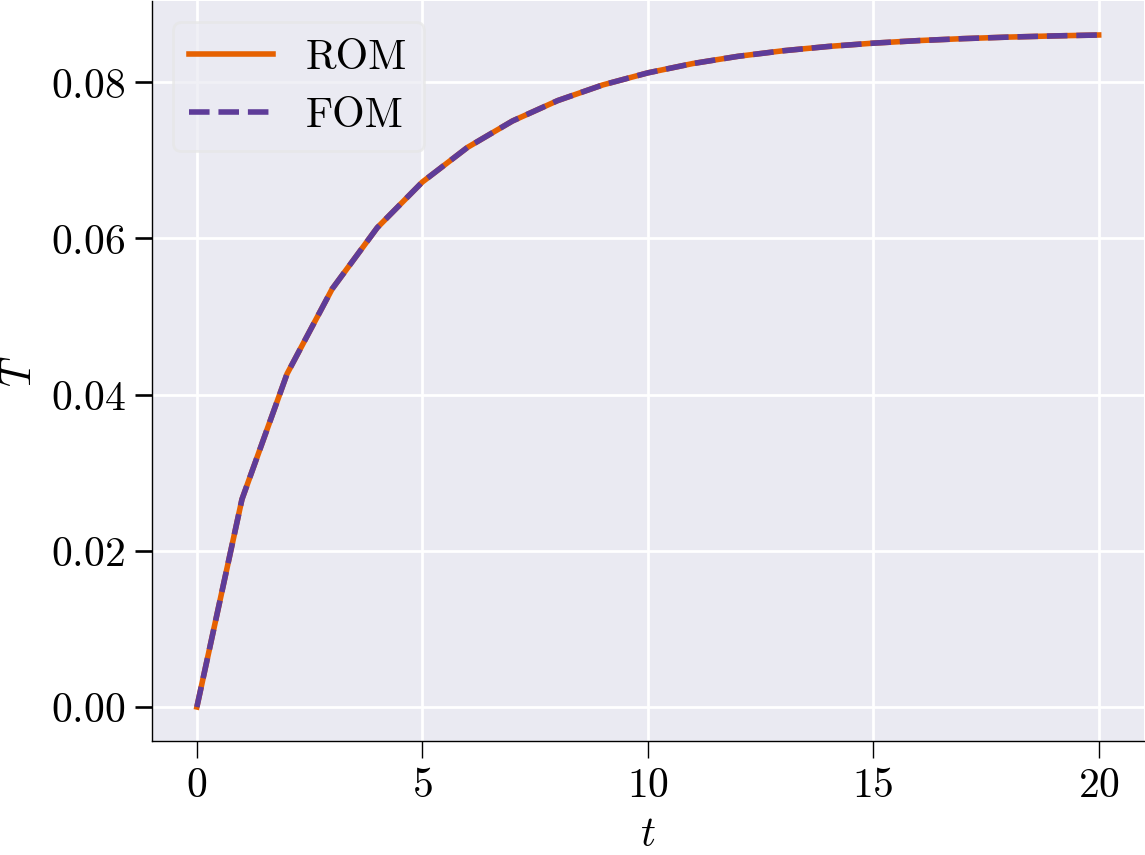

In [33]:
if rom_report:
    RS = np.asarray(rom.rom_solutions)
    plt.plot(RS[0, :, 300])
    plt.plot(rom_data.fos_solutions[rom_data.test_mask][0, :, 300], '--')
    plt.legend(['ROM', 'FOM'])
    # plt.title('Temperature at node 300 over time')
    plt.xlabel('$t$')
    plt.ylabel('$T$')